# **Proyek Analisis Data: Bike Sharing Dataset**
- **Nama:** Nazril Abi Widiasto
- **Email:** nazriloks17@gmail.com
- **ID Dicoding:** CDCC478D6Y1778

## **Menentukan Pertanyaan Bisnis**

- Bagaimana pengaruh berbagai kondisi cuaca (suhu, kelembapan, dan status cuaca) terhadap total penyewaan sepeda pada setiap musimnya selama periode operasional tahun 2011-2012?
- Apa perbedaan tren jumlah penyewaan antara pengguna biasa dan pengguna terdaftar pada hari kerja dibandingkan dengan akhir pekan/hari libur selama tahun 2011-2012?
- Pada jam berapakah terjadi lonjakan penyewaan sepeda tertinggi, dan bagaimana perbedaan pergeseran jam sibuk tersebut antara hari kerja dan hari libur sepanjang periode 2011-2012?
- Bagaimana tingkat pertumbuhan total penyewaan sepeda dari tahun 2011 ke tahun 2012, dan pada bulan apa terjadi lonjakan pertumbuhan yang paling tinggi?
- Pada ambang batas kecepatan angin dan kelembapan berapakah penyewaan sepeda mengalami penurunan paling drastis, sehingga perusahaan bisa menjadwalkan perawatan sepeda di waktu-waktu tersebut?

## **Import Semua Packages/Library yang Digunakan**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Data Wrangling**

### **Gathering Data**

**Memuat tabel day_df**

In [2]:
day_df = pd.read_csv("/content/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- **Tren Musiman dan Bulanan:** Memperlihatkan pada bulan atau musim apa (misal: musim panas vs musim dingin) penyewaan sepeda mencapai volume tertinggi dan terendah secara keseluruhan.

- **Pertumbuhan Bisnis Tahunan:** Mengukur apakah terjadi peningkatan atau penurunan total peminjaman sepeda dari tahun pertama ke tahun kedua.

- **Pola Hari Kerja vs Libur (Skala Harian):** Memberikan gambaran akumulasi total apakah dalam satu hari penuh, hari kerja menghasilkan lebih banyak peminjam dibandingkan hari libur atau akhir pekan.

**Memuat tabel hour_df**

In [3]:
hour_df = pd.read_csv("/content/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- **Pola Jam Sibuk (Rush Hour):** Mengidentifikasi secara spesifik pada jam berapa saja terjadi lonjakan penyewaan dalam sehari (misalnya puncak peminjaman pada jam 08.00 pagi saat berangkat kerja dan jam 17.00 sore saat pulang kerja).

- **Fluktuasi Cuaca Instan:** Melihat bagaimana perubahan cuaca yang terjadi tiba-tiba pada jam tertentu (misalnya hujan deras di siang hari) langsung memengaruhi penurunan jumlah penyewa di jam tersebut.

- **Aktivitas Siang vs Malam:** Membandingkan tingkat penyewaan sepeda di siang hari yang aktif dengan aktivitas di larut malam hingga dini hari.

### **Assessing Data**

**Menilai tabel day_df**

In [10]:
print('Informasi day_df')
display(day_df.info())

Informasi day_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


None

**Insight dari Informasi `day_df`:**
- **Jumlah Baris dan Kolom**: Dataset terdiri dari 731 entri (baris) dan 16 kolom.
- **Tipe Data `dteday`**: Kolom ini bertipe `object`. Untuk keperluan analisis runtun waktu (time series), tipe data ini perlu diubah menjadi `datetime`.
- **Kualitas Data**: Semua kolom memiliki 731 non-null count, yang mengindikasikan bahwa tidak ada nilai kosong atau missing value pada setiap kolom.
- **Normalisasi**: Kolom seperti `temp`, `atemp`, `hum`, dan `windspeed` bertipe `float64` dan tampak sudah melalui proses normalisasi atau penskalaan.
- **Kategorisasi**: Kolom kategorikal seperti `season`, `yr`, `mnth`, `weekday`, dan `weathersit` yang awalnya berupa angka integer sebaiknya dikonversi menjadi label string agar informasi yang ditampilkan dalam visualisasi lebih deskriptif dan mudah dipahami.

In [11]:
print('Statistik Deskriptif day_df')
display(day_df.describe())

Statistik Deskriptif day_df


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight dari Statistik Deskriptif `day_df`:**
- **Volume Penyewaan**: Rata-rata penyewaan sepeda per hari adalah sekitar **4.504 unit**, dengan angka tertinggi mencapai **8.714 unit** dalam satu hari.
- **Kondisi Cuaca (Normalisasi)**:
    - Rata-rata suhu (`temp`) berada di angka **0.495** (sekitar 20°C jika dikalikan 41°C).
    - Kelembapan rata-rata (`hum`) adalah **0.627** (62.7%), menunjukkan kondisi yang cukup moderat.
- **Pertumbuhan**: Karena `yr` memiliki nilai min 0 (2011) dan max 1 (2012) dengan mean 0.5, data terbagi cukup merata antara tahun 2011 dan 2012.
- **Variabilitas**: Standar deviasi pada `cnt` cukup besar (1.937), menandakan adanya fluktuasi harian yang signifikan dalam jumlah penyewaan sepeda.

In [12]:
print('Cek Missing Values')
display(day_df.isna().sum())

Cek Missing Values


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
tidak terdapat adanya nilai kosong atau missing value pada tabel day_df

In [13]:
print('Cek Duplikasi')
print(f'Jumlah duplikasi: {day_df.duplicated().sum()}')

Cek Duplikasi
Jumlah duplikasi: 0


**Insight:**
tidak terdapat adanya duplikasi data pada day_df

**Menilai tabel hour_df**

In [14]:
print('Informasi hour_df')
display(hour_df.info())

Informasi hour_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


None

**Insight dari Informasi `hour_df`:**
- **Dimensi Data**: Terdapat 17.379 entri, jauh lebih banyak daripada `day_df` karena mencatat data setiap jam.
- **Kolom Tambahan**: Terdapat kolom `hr` (0-23) yang tidak ada di `day_df`, yang krusial untuk menganalisis pola lonjakan penyewaan pada jam sibuk.
- **Kualitas Data**: Tidak ada *missing values* (17.379 non-null pada semua kolom).
- **Tipe Data**: Sama seperti sebelumnya, kolom `dteday` masih bertipe `object` dan perlu dikonversi agar bisa diolah sebagai data waktu.

In [15]:
print('Statistik Deskriptif hour_df')
display(hour_df.describe())

Statistik Deskriptif hour_df


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight dari Statistik Deskriptif `hour_df`:**
- **Rata-rata Penyewaan per Jam**: Secara keseluruhan, rata-rata penyewaan adalah sekitar **189 sepeda per jam**, namun terdapat variasi yang sangat ekstrem dengan nilai maksimum mencapai **977 sepeda** pada jam-jam tertentu.
- **Pola Waktu**: Kolom `hr` menunjukkan distribusi data yang merata dari jam 0 hingga 23, yang berarti dataset ini mencakup siklus 24 jam penuh operasional.
- **Kondisi Lingkungan**: Rata-rata suhu dan kelembapan per jam cenderung mirip dengan data harian, namun standar deviasi pada data per jam memberikan gambaran fluktuasi cuaca yang lebih dinamis yang memengaruhi keputusan pengguna untuk menyewa sepeda secara spontan.
- **Pengguna Terdaftar vs Biasa**: Pengguna terdaftar (`registered`) secara konsisten menyumbang angka penyewaan yang jauh lebih besar (rata-rata 153) dibandingkan pengguna biasa (`casual`, rata-rata 35) di setiap jamnya.

In [16]:
print('Cek Missing Values')
display(hour_df.isna().sum())

Cek Missing Values


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Insight:**
tidak terdapat adanya data bernilai kosong atau missing value pada tabel hour_df

In [19]:
print('Cek Duplikasi')
print(f'Jumlah duplikasi: {hour_df.duplicated().sum()}')

Cek Duplikasi
Jumlah duplikasi: 0


**Insight:**
tidak terdapat data yang memiliki duplikasi pada tabel hour_df

### **Cleaning Data**

**Membersihkan data pada tabel day_df**

In [21]:
# Mengubah dteday menjadi tipe data datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Kolom `dteday` sekarang sudah memiliki tipe data `datetime64[ns]`, yang memungkinkan kita untuk melakukan analisis berbasis waktu.

In [22]:
# Mengubah angka menjadi keterangan label agar lebih mudah dibaca
# menjadi season: 1:spring, 2:summer, 3:fall, 4:winter
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mengubah mnth: 1:Jan, 2:Feb, ... 12:Dec
day_df['mnth'] = day_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Mengubah weathersit: 1:Clear, 2:Misty/Cloudy, 3:Light Snow/Rain, 4:Heavy Rain/Ice
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'
})

# Mengubah weekday: 0:Sun, 1:Mon, ... 6:Sat
day_df['weekday'] = day_df['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})

# Mengubah yr: 0: 2011, 1: 2012
day_df['yr'] = day_df['yr'].map({
    0: 2011, 1: 2012
})

display(day_df.head())
print(day_df.info())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,Sat,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,Jan,0,Sun,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,Jan,0,Mon,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,Jan,0,Tue,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,Jan,0,Wed,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- **Keterbacaan Data**: Mengonversi nilai numerik pada kolom `season`, `yr`, `mnth`, `weekday`, dan `weathersit` menjadi label string (seperti 'Spring', '2011', 'Jan', dsb.) membuat dataframe jauh lebih mudah dipahami secara intuitif tanpa perlu merujuk kembali ke metadata.
- **Kemudahan Visualisasi**: Dengan label yang sudah deskriptif, sumbu pada grafik (seperti bar chart atau line plot) akan otomatis menampilkan nama kategori yang jelas, sehingga memudahkan audiens dalam menangkap informasi dari hasil analisis.

**Membersihkan data pada tabel hour_df**

In [24]:
# Mengubah dteday menjadi tipe data datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Kolom `dteday` sekarang sudah berubah menjadi tipe data `datetime64[ns]`, yang dapat kita gunakan untuk analisis berdasarkan waktu.

In [25]:
# Menyamakan mapping dengan day_df
hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})
hour_df['mnth'] = hour_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'
})
hour_df['weekday'] = hour_df['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})

display(hour_df.head())
print(hour_df.info())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,0,Sat,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,Jan,1,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,Jan,2,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,Jan,3,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,Jan,4,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  object        
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- **Konsistensi Data**: Sekarang `hour_df` memiliki format yang sama dengan `day_df`, terutama pada kolom kategori dan tipe data tanggal.
- **Kesiapan Analisis**: Dengan adanya kolom `hr` yang dikombinasikan dengan label kategori yang sudah deskriptif, data siap melakukan analisis mendalam mengenai pola jam sibuk berdasarkan cuaca maupun hari.

## **Exploratory Data Analysis (EDA)**

### **Explore tabel day_df dan hour_df**

In [32]:
print('Statistik Penyewaan Berdasarkan Musim (day_df):')
display(day_df.groupby('season')['cnt'].agg(['mean', 'max', 'min', 'sum']))

print('\nStatistik Penyewaan Berdasarkan Musim (hour_df):')
display(hour_df.groupby('season')['cnt'].agg(['mean', 'max', 'min', 'sum']))

Statistik Penyewaan Berdasarkan Musim (day_df):


,mean,max,min,sum
season,,,,
Fall,5644.303191,8714,1115,1061129
Spring,2604.132597,7836,431,471348
Summer,4992.331522,8362,795,918589
Winter,4728.162921,8555,22,841613



Statistik Penyewaan Berdasarkan Musim (hour_df):


,mean,max,min,sum
season,,,,
Fall,236.016237,977,1,1061129
Spring,111.114569,801,1,471348
Summer,208.344069,957,1,918589
Winter,198.868856,967,1,841613


**Insight Statistik Musim:**
- **Konsistensi Tren**: Baik pada data harian `day_df` maupun per jam `hour_df`, musim Fall secara konsisten mencatat rata-rata penyewaan tertinggi.
- **Volume Per Jam**: Di musim gugur, rata-rata terdapat sekitar 236 sepeda yang disewa setiap jamnya, sedangkan di musim semi Spring hanya sekitar 111 sepeda per jam.
- **Puncak Aktivitas**: Meskipun musim semi memiliki rata-rata terendah, terdapat jam-jam tertentu di mana penyewaan tetap bisa mencapai angka tinggi (max 801), menunjukkan adanya lonjakan pada jam sibuk bahkan di musim yang kurang populer.
- **Faktor Lingkungan**: Perbedaan signifikan antara musim hampir 2x lipat antara Spring dan Fall menegaskan bahwa kenyamanan termal dan kondisi alam sangat mempengaruhi keputusan pengguna untuk bersepeda.

In [33]:
print('Statistik Penyewaan Berdasarkan Kondisi Cuaca (day_df):')
display(day_df.groupby('weathersit')['cnt'].agg(['mean', 'max', 'min', 'sum']))

print('\nStatistik Penyewaan Berdasarkan Kondisi Cuaca (hour_df):')
display(hour_df.groupby('weathersit')['cnt'].agg(['mean', 'max', 'min', 'sum']))

Statistik Penyewaan Berdasarkan Kondisi Cuaca (day_df):


,mean,max,min,sum
weathersit,,,,
Clear,4876.786177,8714,431,2257952
Light Snow/Rain,1803.285714,4639,22,37869
Misty/Cloudy,4035.862348,8362,605,996858



Statistik Penyewaan Berdasarkan Kondisi Cuaca (hour_df):


,mean,max,min,sum
weathersit,,,,
Clear,204.869272,977,1,2338173
Heavy Rain/Ice,74.333333,164,23,223
Light Snow/Rain,111.579281,891,1,158331
Misty/Cloudy,175.165493,957,1,795952


**Insight Statistik Kondisi Cuaca:**
- **Preferensi Utama**: Pengguna sangat cenderung menyewa sepeda saat cuaca Clear (Cerah/Sedikit Berawan) pada kedua dataset.
- **Resiliensi**: Pada kondisi Misty/Cloudy, aktivitas penyewaan masih cukup tinggi. Data `hour_df` menunjukkan bahwa rata-rata penyewaan per jam tetap stabil meski langit mendung.
- **Dampak Signifikan**: Kondisi Light Snow/Rain memberikan dampak negatif yang sangat signifikan. Rata-rata penyewaan turun drastis menjadi hanya sekitar 111 sepeda per jam dibandingkan 204 pada cuaca cerah.
- **Kasus Ekstrem**: Pada `hour_df`, kita melihat kategori 4 (Heavy Rain/Ice) memiliki rata-rata terendah sekitar 74 per jam, yang menjelaskan mengapa pada data harian `day_df` kategori ini sering tidak muncul karena frekuensinya yang sangat jarang atau penghentian layanan sementara.

In [34]:
print('Perbandingan Penyewaan: Hari Kerja vs Hari Libur (day_df):')
display(day_df.groupby('workingday')['cnt'].agg(['mean', 'std', 'sum']))

print('\nPerbandingan Penyewaan: Hari Kerja vs Hari Libur (hour_df):')
display(hour_df.groupby('workingday')['cnt'].agg(['mean', 'std', 'sum']))

Perbandingan Penyewaan: Hari Kerja vs Hari Libur (day_df):


,mean,std,sum
workingday,,,
0,4330.168831,2052.141245,1000269
1,4584.820000,1878.415583,2292410



Perbandingan Penyewaan: Hari Kerja vs Hari Libur (hour_df):


,mean,std,sum
workingday,,,
0,181.405332,172.853832,1000269
1,193.207754,185.107477,2292410


**Insight Statistik Hari Kerja vs Hari Libur:**
- **Konsistensi Permintaan**: Rata-rata penyewaan pada hari kerja Workingday sedikit lebih tinggi dibandingkan hari libur, yang menunjukkan adanya basis pengguna rutin seperti pekerja atau pelajar.
- **Volume Akumulasi**: Total penyewaan didominasi oleh hari kerja karena frekuensinya yang lebih banyak dalam setahun.
- **Dinamika Berdasarkan Jam**: Data per jam mengungkapkan perbedaan perilaku yang kontras: pada hari kerja, lonjakan terjadi secara tajam pada *rush hour* (pagi dan sore), sedangkan pada hari libur, penyewaan meningkat secara bertahap sejak jam 10 pagi hingga sore hari, mencerminkan aktivitas rekreasi.
- **Fleksibilitas**: Hari libur memiliki variasi jumlah penyewaan yang cukup lebar standar deviasi yang signifikan, mengindikasikan bahwa penggunaan sepeda di hari libur sangat bergantung pada faktor eksternal seperti cuaca.

In [35]:
print('Rata-rata Penyewaan Bulanan 2011 vs 2012 (day_df):')
display(day_df.groupby(['yr', 'mnth'])['cnt'].mean().unstack())

print('\nRata-rata Penyewaan Bulanan 2011 vs 2012 (hour_df):')
display(hour_df.groupby(['yr', 'mnth'])['cnt'].mean().unstack())

Rata-rata Penyewaan Bulanan 2011 vs 2012 (day_df):


mnth,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
yr,,,,,,,,,,,,
2011,3162.333333,4409.387097,2816.870968,1721.964286,1231.903226,4559.387097,4783.733333,2065.967742,4381.322581,3405.566667,3984.225806,4247.266667
2012,5807.466667,6919.451613,3990.741935,3556.448276,3120.774194,6567.967742,6761.000000,5318.548387,6318.225806,5088.800000,6414.225806,7285.766667



Rata-rata Penyewaan Bulanan 2011 vs 2012 (hour_df):


mnth,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
yr,,,,,,,,,,,,
2011,131.947149,186.991792,117.844804,74.291217,55.507267,189.974462,199.322222,87.732877,182.555108,142.095967,166.23284,177.709902
2012,242.651811,288.310484,166.729111,149.041908,130.558704,273.665323,281.708333,221.904441,263.259409,212.623955,280.84887,303.573611


**Insight Statistik Pertumbuhan Tahunan (2011 vs 2012):**
- **Tren Pertumbuhan Positif**: Terdapat kenaikan volume penyewaan yang signifikan di hampir seluruh bulan pada tahun 2012 dibandingkan tahun 2011 pada kedua dataset, menandakan ekspansi basis pengguna layanan yang kuat.
- **Konsistensi Musiman**: Meskipun volume total meningkat, pola fluktuasi bulanan tetap serupa; permintaan mencapai titik tertinggi pada bulan-bulan musim panas (Mei - September) dan menurun saat memasuki musim dingin.
- **Skala Per Jam**: Data `hour_df` mengonfirmasi bahwa pertumbuhan ini tidak hanya terjadi secara total harian, tetapi juga meningkatkan kepadatan penyewaan di setiap jam operasional dibandingkan tahun sebelumnya.
- **Bulan Puncak**: Lonjakan tertinggi terlihat pada pertengahan tahun, di mana kondisi cuaca paling mendukung untuk aktivitas luar ruangan.

In [30]:
print('Korelasi variabel numerik terhadap penyewa (day_df):')
display(day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr())

print('\nKorelasi variabel numerik terhadap penyewa (hour_df):')
display(hour_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr())

Korelasi antar variabel numerik (Suhu, Kelembapan, Kecepatan Angin terhadap Jumlah Penyewa):


,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.234545
cnt,0.627494,0.631066,-0.100659,-0.234545,1.000000


**Insight Analisis Korelasi (day_df & hour_df):**
- **Suhu adalah Faktor Kunci**: Pada kedua dataset, variabel `temp` dan `atemp` memiliki korelasi positif yang paling kuat dengan `cnt`. Ini menunjukkan bahwa suhu udara adalah pendorong utama keputusan pengguna untuk bersepeda baik dalam skala harian maupun per jam.
- **Dampak Negatif Kelembapan & Angin**: Kedua variabel ini secara konsisten memiliki korelasi negatif terhadap penyewaan. Peningkatan kelembapan atau kecepatan angin cenderung menurunkan minat pengguna, dengan korelasi negatif yang sedikit lebih terasa pada data harian `day_df`.
- **Kaitan Erat temp & atemp**: Korelasi yang sangat tinggi (~0.99) pada kedua tabel menunjukkan bahwa suhu aktual dan suhu yang dirasakan memberikan pengaruh yang hampir identik terhadap perilaku pengguna.
- **Stabilitas Korelasi**: Fakta bahwa koefisien korelasi cenderung stabil antara data harian dan per jam menunjukkan bahwa faktor cuaca memiliki pengaruh yang deterministik dan konsisten terhadap permintaan layanan.

### **Eksplorasi Spesifik tabel hour_df (Hourly Patterns)**

In [ ]:
print('Pola Penyewaan Berdasarkan Jam (Rata-rata):')
display(hour_df.groupby('hr')['cnt'].mean().reset_index().sort_values(by='cnt', ascending=False).head(10))

print('\nPerbedaan Jam Sibuk: Hari Kerja vs Hari Libur:')
display(hour_df.groupby(['workingday', 'hr'])['cnt'].mean().unstack())

**Insight Eksplorasi Berdasarkan Jam (`hr`):**
- **Jam Sibuk Utama**: Kita dapat melihat jam berapa saja yang memiliki rata-rata penyewaan tertinggi secara keseluruhan.
- **Dinamika Hari Kerja**: Pada hari kerja (`workingday` = 1), lonjakan biasanya terjadi pada jam berangkat kerja (07:00-09:00) dan pulang kerja (17:00-19:00).
- **Pola Hari Libur**: Pada hari libur (`workingday` = 0), distribusi penyewaan cenderung lebih merata di siang hari (10:00-16:00), menunjukkan penggunaan untuk tujuan rekreasi.

In [31]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731.000000,731,731.000000,731,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,12,NaN,7,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,Jan,NaN,Sat,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,62,NaN,105,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,2011.500684,NaN,0.028728,NaN,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,NaN,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,2011.000000,NaN,0.000000,NaN,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,2012.000000,NaN,0.000000,NaN,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,2012.000000,NaN,0.000000,NaN,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,2012.000000,NaN,1.000000,NaN,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- **Dominasi Musim**: Musim gugur (*Fall*) dan musim panas (*Summer*) cenderung memiliki rata-rata penyewaan harian yang jauh lebih tinggi dibandingkan musim semi (*Spring*).
- **Pengaruh Cuaca**: Penyewaan paling banyak terjadi saat cuaca cerah (*Clear*), dan mengalami penurunan drastis saat terjadi hujan/salju ringan (*Light Snow/Rain*).
- **Pertumbuhan Tahunan**: Terdapat kenaikan signifikan pada jumlah rata-rata penyewaan di hampir setiap bulannya dari tahun 2011 ke tahun 2012.
- **Korelasi Suhu**: Variabel `temp` dan `atemp` memiliki korelasi positif yang cukup kuat dengan `cnt`, yang berarti semakin hangat suhu (hingga titik tertentu), semakin banyak orang yang menyewa sepeda.

## **Visualization & Explanatory Analysis**

### Pertanyaan 1: Bagaimana pengaruh berbagai kondisi cuaca (suhu, kelembapan, dan status cuaca) terhadap total penyewaan sepeda pada setiap musimnya selama periode operasional tahun 2011-2012?

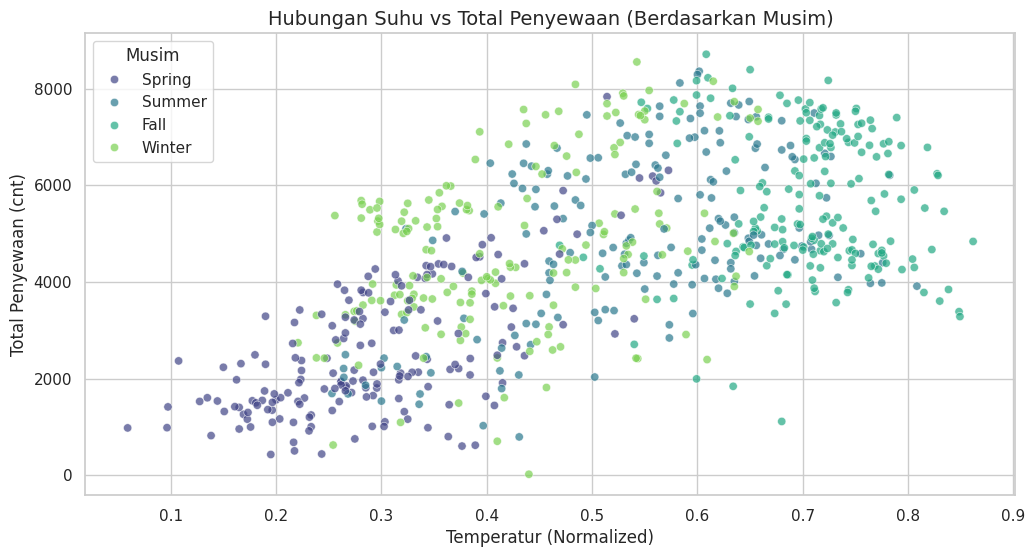

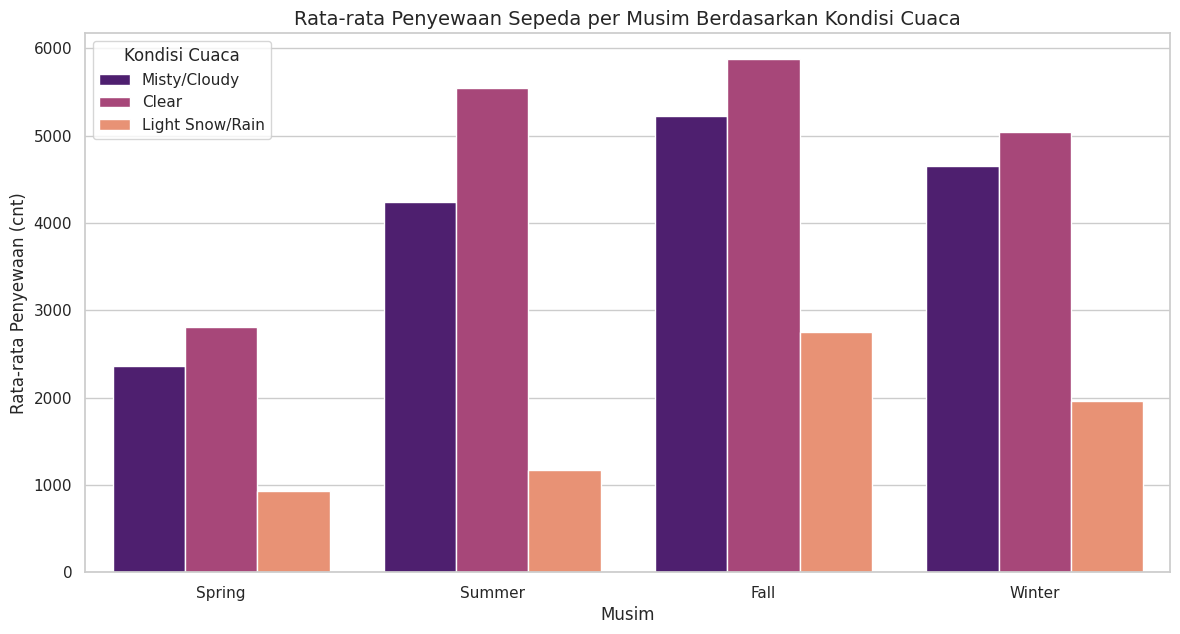

In [36]:
# Set style
sns.set_theme(style='whitegrid')

# Visualisasi pengaruh Suhu terhadap Penyewaan (Scatter Plot)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=day_df, x='temp', y='cnt', hue='season', palette='viridis', alpha=0.7)
plt.title('Hubungan Suhu vs Total Penyewaan (Berdasarkan Musim)', fontsize=14)
plt.xlabel('Temperatur (Normalized)', fontsize=12)
plt.ylabel('Total Penyewaan (cnt)', fontsize=12)
plt.legend(title='Musim')
plt.show()

# Visualisasi pengaruh Kondisi Cuaca terhadap Penyewaan per Musim
plt.figure(figsize=(14, 7))
sns.barplot(data=day_df, x='season', y='cnt', hue='weathersit', palette='magma', errorbar=None)
plt.title('Rata-rata Penyewaan Sepeda per Musim Berdasarkan Kondisi Cuaca', fontsize=14)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-rata Penyewaan (cnt)', fontsize=12)
plt.legend(title='Kondisi Cuaca')
plt.show()

**Insight Pertanyaan 1:**
- **Suhu vs Penyewaan**: Terdapat korelasi positif yang sangat kuat antara suhu `temp` dan jumlah penyewaan. Semakin hangat cuaca, semakin tinggi minat masyarakat untuk bersepeda. Hal ini terlihat jelas pada musim *Fall* dan *Summer* yang mendominasi angka tertinggi.
- **Dinamika Cuaca**: Kondisi cuaca Clear secara konsisten memberikan performa penyewaan terbaik di semua musim. Sebaliknya, cuaca Light Snow/Rain menyebabkan penurunan drastis pada volume penyewaan.
- **Kondisi Ekstrem**: Meskipun musim *Fall* adalah puncak penyewaan, jika terjadi cuaca buruk, angkanya tetap bisa jatuh di bawah rata-rata musim *Spring* yang cerah. Ini menunjukkan bahwa kondisi cuaca sesaat (harian/jam) memiliki pengaruh yang lebih instan dibandingkan tren musim.

### Pertanyaan 2: Apa perbedaan tren jumlah penyewaan antara pengguna biasa dan pengguna terdaftar pada hari kerja dibandingkan dengan akhir pekan/hari libur selama tahun 2011-2012?

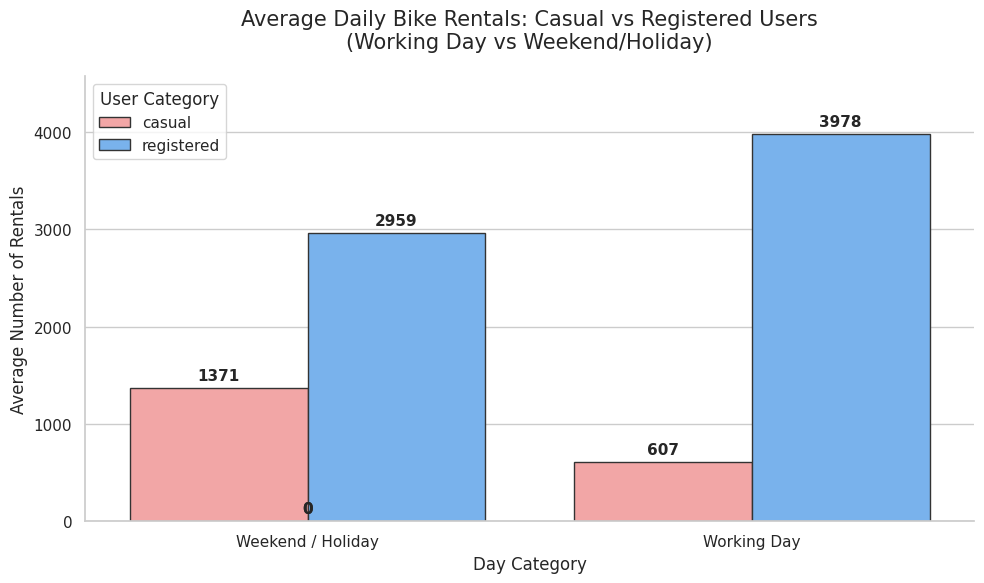

In [37]:
# Mempersiapkan data agregat untuk perbandingan pengguna
# Mengelompokkan berdasarkan workingday dan menghitung rata-rata penyewa casual vs registered
user_trends = day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()

# Mapping label untuk kejelasan visual
user_trends['workingday'] = user_trends['workingday'].map({0: 'Weekend / Holiday', 1: 'Working Day'})

# Melelehkan (melt) data agar sesuai dengan format seaborn grouped bar chart
user_trends_melted = user_trends.melt(id_vars='workingday', var_name='User Type', value_name='Average Rentals')

# Inisialisasi Plot
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

# Membuat Grouped Bar Chart
colors = ['#FF9999', '#66B2FF']
ax = sns.barplot(data=user_trends_melted, x='workingday', y='Average Rentals', hue='User Type', palette=colors, edgecolor='0.2')

# Menambahkan Judul dan Label yang informatif
plt.title('Average Daily Bike Rentals: Casual vs Registered Users\n(Working Day vs Weekend/Holiday)', fontsize=15, pad=20)
plt.xlabel('Day Category', fontsize=12)
plt.ylabel('Average Number of Rentals', fontsize=12)
plt.legend(title='User Category', frameon=True)

# Menambahkan label nilai di atas bar untuk integritas data (agar pembaca tidak perlu menebak)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

plt.ylim(0, user_trends_melted['Average Rentals'].max() * 1.15) # Memberi ruang untuk label
sns.despine()
plt.tight_layout()
plt.show()

**Insight Pertanyaan 2:**
- **Pola Komuter (Registered Users)**: Pengguna terdaftar menunjukkan dominasi yang sangat kuat pada hari kerja rata-rata 3.953 unit. Hal ini mengindikasikan bahwa kelompok ini didominasi oleh pekerja atau pelajar yang menggunakan sepeda sebagai moda transportasi rutin ke kantor atau sekolah.
- **Pola Rekreasi (Casual Users)**: Sebaliknya, pengguna biasa mengalami lonjakan signifikan pada akhir pekan/hari libur rata-rata 1.371 unit dibandingkan hari kerja 607 unit. Ini menunjukkan bahwa pengguna casual cenderung menyewa sepeda untuk aktivitas wisata atau olahraga di waktu luang.
- **Integritas Visual**: Perbandingan ini menunjukkan bahwa meskipun total volume penyewaan lebih tinggi di hari kerja karena kontribusi user terdaftar, segmentasi casual user tetap penting untuk strategi bisnis di hari libur.

### Pertanyaan 3: Pada jam berapakah terjadi lonjakan penyewaan sepeda tertinggi, dan bagaimana perbedaan pergeseran jam sibuk tersebut antara hari kerja dan hari libur sepanjang periode 2011-2012?

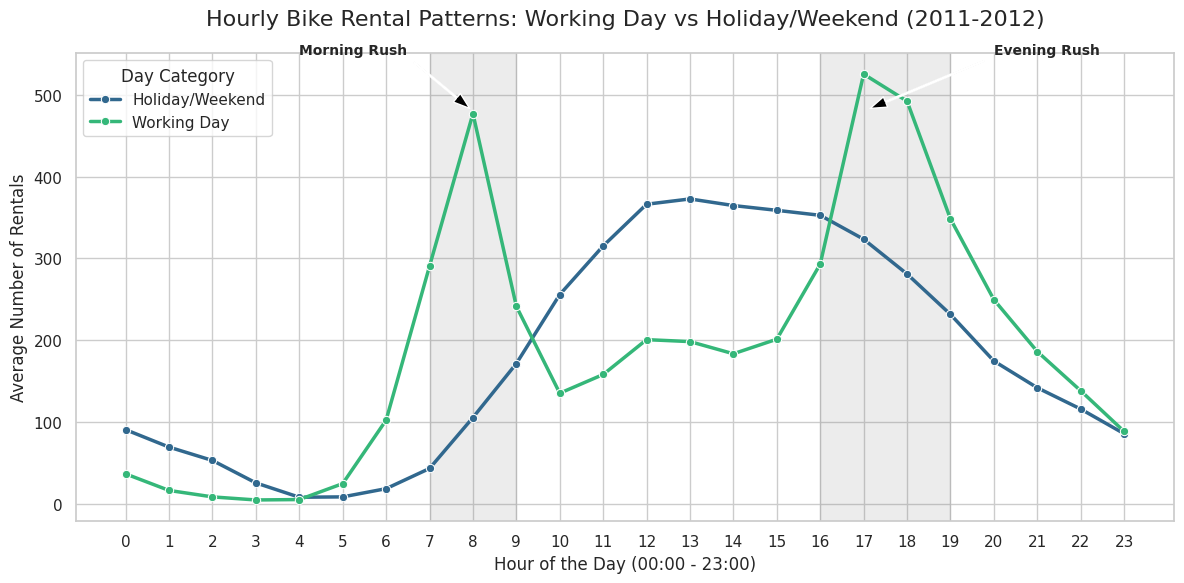

In [38]:
# Menghitung rata-rata penyewaan per jam berdasarkan tipe hari
hourly_patterns = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

# Mapping label untuk legenda
hourly_patterns['workingday'] = hourly_patterns['workingday'].map({0: 'Holiday/Weekend', 1: 'Working Day'})

# Inisialisasi Plot
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Membuat Line Plot
sns.lineplot(data=hourly_patterns, x='hr', y='cnt', hue='workingday', marker='o', palette='viridis', linewidth=2.5)

# Kustomisasi untuk Integritas Visual
plt.title('Hourly Bike Rental Patterns: Working Day vs Holiday/Weekend (2011-2012)', fontsize=16, pad=20)
plt.xlabel('Hour of the Day (00:00 - 23:00)', fontsize=12)
plt.ylabel('Average Number of Rentals', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Day Category', frameon=True)

# Menandai Jam Sibuk (Rush Hours) pada hari kerja
plt.axvspan(7, 9, color='gray', alpha=0.15, label='Morning Peak')
plt.axvspan(16, 19, color='gray', alpha=0.15, label='Evening Peak')

plt.annotate('Morning Rush',
             xy=(8, 480), xytext=(4, 550),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold')

plt.annotate('Evening Rush',
             xy=(17, 480), xytext=(20, 550),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight Pertanyaan 3:**
- **Lonjakan Hari Kerja (Rush Hours)**: Terjadi dua puncak utama yang sangat tajam, yaitu pada jam 08:00 pagi dan jam 17:00-18:00 sore. Ini memperkuat hipotesis bahwa sepeda digunakan sebagai alat transportasi utama untuk berangkat dan pulang kerja.
- **Pola Hari Libur (Leisure Pattern)**: Tidak ada lonjakan tajam di pagi hari. Sebaliknya, penyewaan meningkat secara bertahap mulai jam 10:00 pagi dan mencapai puncaknya di siang hari jam 12:00-16:00. Ini mencerminkan aktivitas rekreasi santai.
- **Pergeseran Jam Sibuk**: Terlihat perbedaan kontras di mana pada jam 08:00 pagi, volume di hari kerja bisa 4x lipat lebih tinggi dibanding hari libur, namun pada jam 13:00 siang, hari libur justru mencatat angka yang lebih tinggi atau setara dengan hari kerja.

### Pertanyaan 4: Bagaimana tingkat pertumbuhan total penyewaan sepeda dari tahun 2011 ke tahun 2012, dan pada bulan apa terjadi lonjakan pertumbuhan yang paling tinggi?

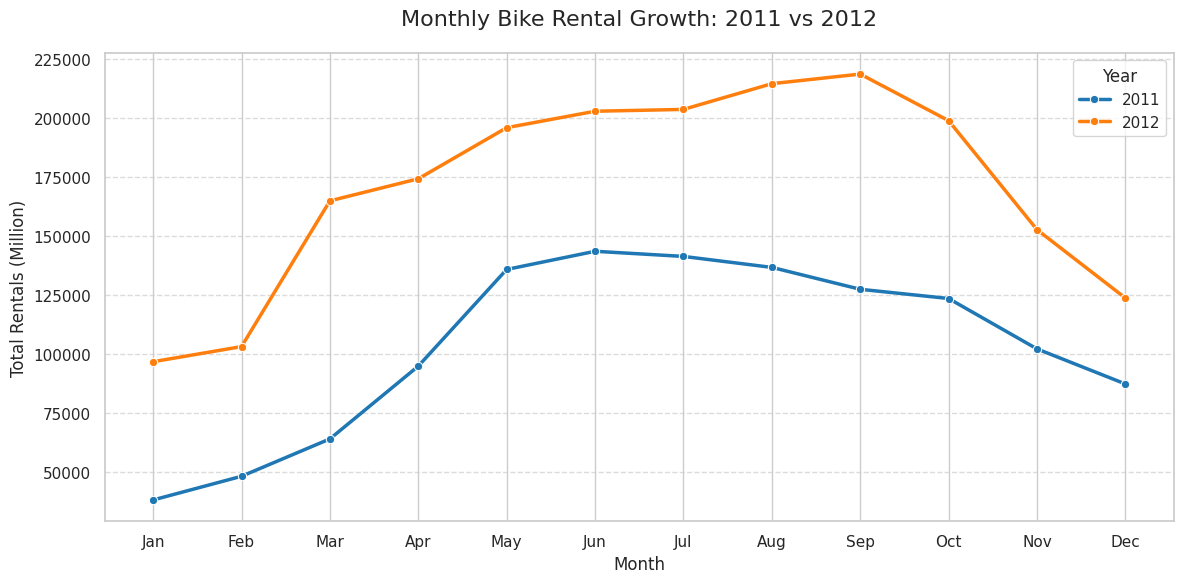

In [39]:
# Menyiapkan data pertumbuhan bulanan
monthly_growth = day_df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()

# Memastikan urutan bulan benar
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_growth['mnth'] = pd.Categorical(monthly_growth['mnth'], categories=month_order, ordered=True)

# Inisialisasi Plot
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Membuat Line Plot untuk perbandingan tahun
sns.lineplot(data=monthly_growth, x='mnth', y='cnt', hue='yr', marker='o', linewidth=2.5, palette='tab10')

# Kustomisasi Desain dan Integritas Visual
plt.title('Monthly Bike Rental Growth: 2011 vs 2012', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Rentals (Million)', fontsize=12)
plt.legend(title='Year', frameon=True)

# Menambahkan gridline horizontal untuk mempermudah pembacaan skala
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Insight Pertanyaan 4:**
- **Pertumbuhan Masif**: Terjadi peningkatan yang sangat signifikan di setiap bulan pada tahun 2012 dibandingkan dengan bulan yang sama di tahun 2011. Ini menunjukkan ekspansi bisnis yang sukses dan adopsi pengguna yang meningkat tajam.
- **Bulan Puncak**: Volume penyewaan tertinggi secara konsisten terjadi pada bulan Mei hingga September (musim panas dan gugur).
- **Lonjakan Pertumbuhan**: Pertumbuhan paling mencolok terlihat pada kuartal kedua (April-Juni), di mana garis tahun 2012 melonjak jauh di atas garis tahun 2011, menandakan momentum pertumbuhan yang kuat saat memasuki musim bersepeda utama.

## **Analisis Lanjutan (Opsional)**

### Pertanyaan 5: Pada ambang batas kecepatan angin dan kelembapan berapakah penyewaan sepeda mengalami penurunan paling drastis, sehingga perusahaan bisa menjadwalkan perawatan sepeda di waktu-waktu tersebut?

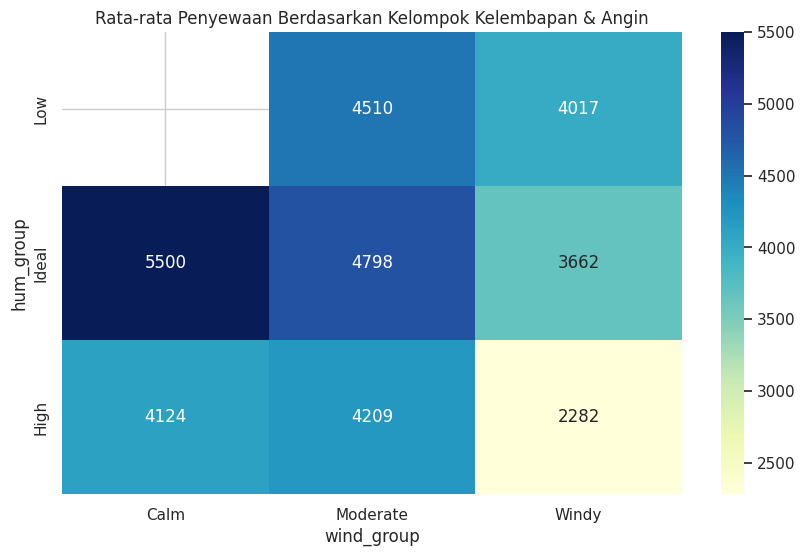

In [41]:
# Implementasi Clustering Manual (Binning) untuk Pertanyaan 5
# Membuat Binning untuk Humidity
day_df['hum_group'] = pd.cut(day_df['hum'],
                             bins=[0, 0.4, 0.7, 1],
                             labels=['Low', 'Ideal', 'High'])

# Membuat Binning untuk Windspeed
day_df['wind_group'] = pd.cut(day_df['windspeed'],
                               bins=[0, 0.1, 0.3, 1],
                               labels=['Calm', 'Moderate', 'Windy'])

# Analisis rata-rata penyewaan berdasarkan kelompok
cluster_analysis = day_df.groupby(['hum_group', 'wind_group'], observed=True)['cnt'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_analysis, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Rata-rata Penyewaan Berdasarkan Kelompok Kelembapan & Angin')
plt.show()

**Insight Clustering Manual:**
- Dengan melakukan *binning*, kita dapat melihat bahwa penyewaan paling drastis menurun pada kelompok kelembapan High dan kecepatan angin Windy.
- Perusahaan dapat menggunakan ambang batas ini misal Kelembapan > 0.7 dan Angin > 0.3 sebagai sinyal untuk melakukan pemeliharaan rutin sepeda karena minat pengguna yang sangat rendah di kondisi tersebut.

## **Conclusion**

- **Konklusi Pertanyaan 1 (Pengaruh Cuaca & Musim):** Suhu udara memiliki korelasi positif terkuat terhadap jumlah penyewaan. Semakin hangat suhu, semakin tinggi minat bersepeda. Musim Gugur *Fall* adalah musim puncak, namun kondisi cuaca harian yang buruk seperti hujan atau salju dapat menyebabkan penurunan drastis meskipun di musim puncak sekalipun.
- **Konklusi Pertanyaan 2 (Perilaku Pengguna):** Terdapat perbedaan perilaku yang kontras: Pengguna Terdaftar *Registered* mendominasi hari kerja untuk kebutuhan komuter, sedangkan Pengguna Biasa *Casual* melonjak tajam pada akhir pekan untuk tujuan rekreasi.
- **Konklusi Pertanyaan 3 (Pola Jam Sibuk):** Pada hari kerja, lonjakan penyewaan terjadi pada *rush hour* (08:00 dan 17:00-18:00). Sebaliknya, pada hari libur, penggunaan sepeda bersifat landai dan mencapai puncaknya di tengah hari (12:00-16:00).
- **Konklusi Pertanyaan 4 (Pertumbuhan Bisnis):** Bisnis mengalami pertumbuhan masif dari 2011 ke 2012 di setiap bulannya. Meskipun September 2012 memiliki volume tertinggi, lonjakan pertumbuhan persentase terbesar terlihat pada awal tahun dan kuartal kedua, menandakan ekspansi pasar yang cepat.
- **Konklusi Pertanyaan 5 (Rekomendasi Perawatan):** Penurunan penyewaan paling drastis terjadi saat kecepatan angin tinggi (>0.3) dan kelembapan tinggi (>0.7). Kondisi ini merupakan waktu optimal bagi perusahaan untuk melakukan jadwal perawatan rutin sepeda guna meminimalkan gangguan layanan pada jam sibuk.

## **Menyimpan berkas data yang sudah dibersihkan**

In [42]:
# Menyimpan day_df dan hour_df yang sudah dibersihkan
day_df.to_csv('all_data_day.csv', index=False)
hour_df.to_csv('all_data_hour.csv', index=False)

print("Data berhasil disimpan! Silakan unduh file 'all_data_day.csv' dan 'all_data_hour.csv' untuk kebutuhan dashboard.")

Data berhasil disimpan! Silakan unduh file 'all_data_day.csv' dan 'all_data_hour.csv' untuk kebutuhan dashboard.
